In [23]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# Real Data management
import os
import scipy.io

# Imports for math and graphics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy
from kneed import KneeLocator

# Our package
import neuro_lib as nlib
from neuro_lib.plotting import TE_heatMat
from neuro_lib.transfer_entropy import transfer_entropy_matrix

# MUTUAL INFORMATION ESTIMATION ON REAL BRAIN DATA TIME SERIES

## Data description

The data are brain signals recorded via resting-state functional MRI (fMRI).  
Each of the two matrices contains **1200 time points** for **119 brain regions**.  
The two matrices correspond to two recording sessions of the same subject  
(ideally, they could be used to verify the consistency of the estimates).

## Tasks

1. If computationally feasible, calculate a **transfer entropy matrix** of size 119 × 119,  
   where the element (i,j) represents the **transfer entropy** from the i-th signal to the j-th signal.
2. Compare the matrices obtained using different methods.
3. Evaluate the **consistency** of the results across the two sessions.

**Note:** If the computation is too heavy, you can restrict yourself to a **subset of the time series**  
(for example, the first 10 regions or even just the first 2).

# Load the data

In [25]:
# Define the data directory
data_dir = "Data"

# Define the file names
file1 = "100307.REST1.LR.SchaeferS.ptseries.mat"
file2 = "100307.REST2.LR.SchaeferS.ptseries.mat"

# Construct full paths
path1 = os.path.join(data_dir, file1)
path2 = os.path.join(data_dir, file2)

# Load the .mat files
data1 = scipy.io.loadmat(path1)
data2 = scipy.io.loadmat(path2)

# Check the keys in the loaded data
print("Keys in REST1 data:", data1.keys())
print("Keys in REST2 data:", data2.keys())

# Get time series
data1_mat = data1['tseries']  # shape (119, 1200)
data2_mat = data2['tseries']  # shape (119, 1200)

Keys in REST1 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])
Keys in REST2 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


# TE IMPLEMENTATIONS

Transfer Entropy from a source signal $S$ to a target signal $X$ is defined as:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

where $\ell$ is the chosen lag.

# Binning

The binning approach estimates entropies by discretizing continuous variables:

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Discretization:**
   Each variable is divided into $n_{\text{bins}}$ intervals, and empirical counts are computed.

3. **Conditional entropy estimation:**
   - $H(X_t \mid X_{t-1})$ is computed using a 2D histogram
   - $H(X_t \mid X_{t-1}, S_{t-\ell})$ is computed using a 3D histogram

4. **Transfer Entropy:**
$$
TE = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

#### Notes

- A Miller bias correction can optionally be applied.
- The method is fully non-parametric.
- It can capture nonlinear dependencies, but is sensitive to:
  - number of bins
  - finite sample effects (especially in higher dimensions)

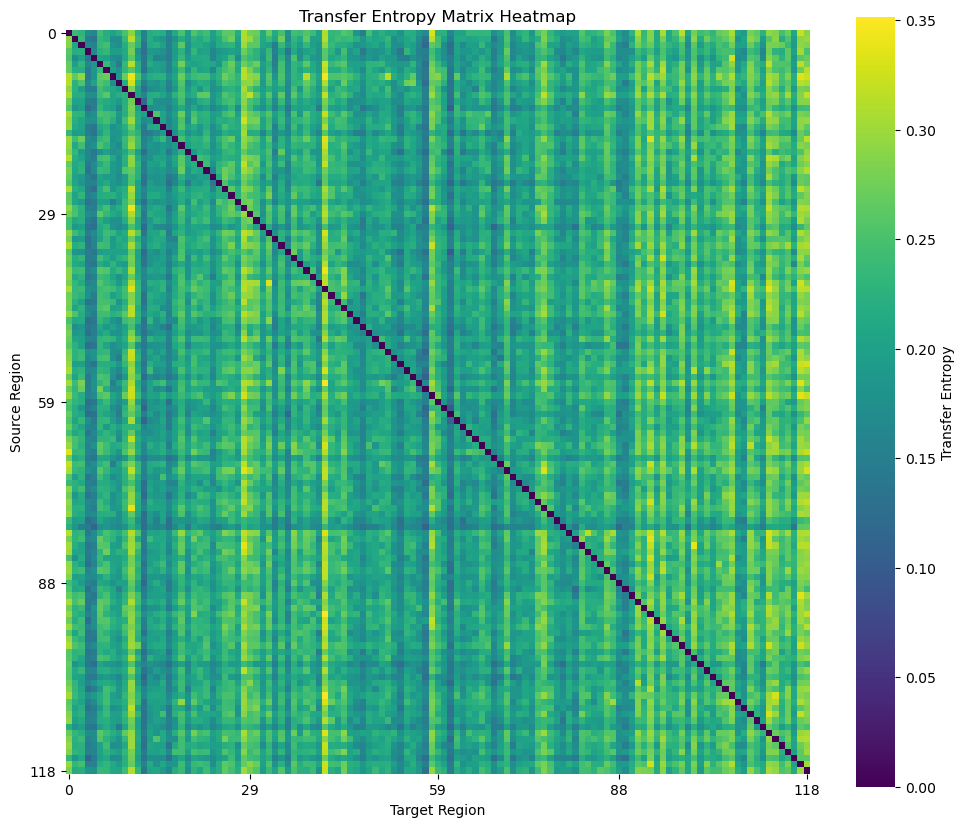

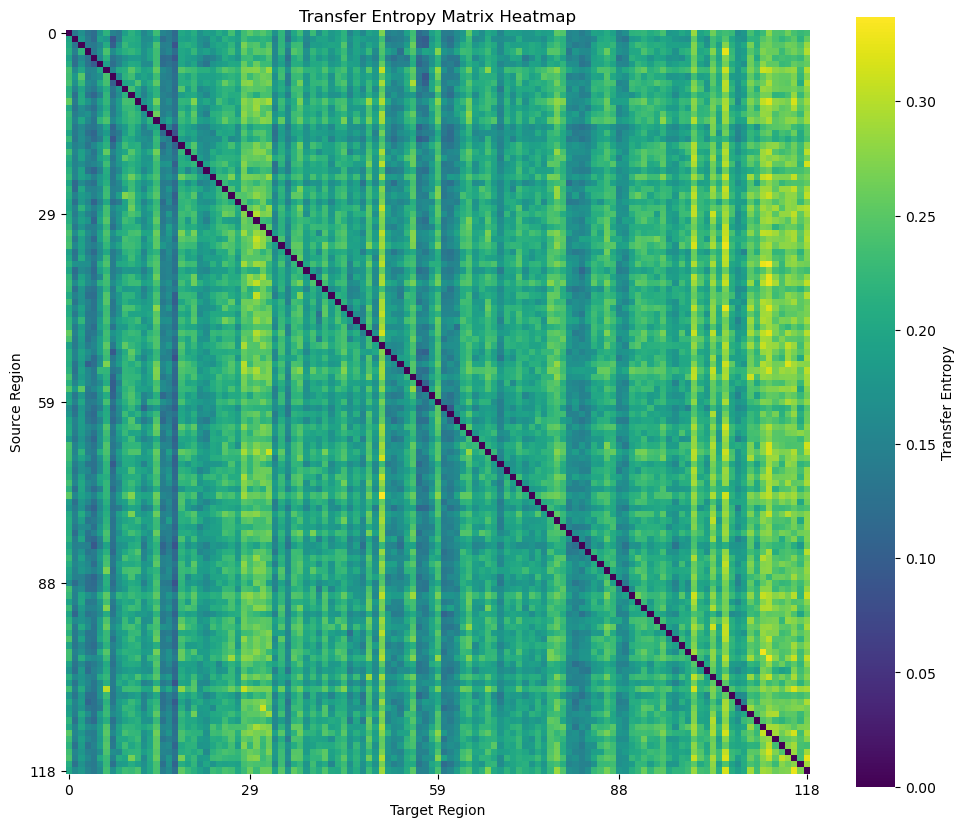

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [26]:
nbins = int(1200**(1/3))
TE_mat_1 = nlib.transfer_entropy_matrix(data1_mat, n_bins=nbins, lag=1)
TE_mat_2 = nlib.transfer_entropy_matrix(data2_mat, n_bins=nbins, lag=1)
TE_heatMat(TE_mat_1, figsize=(12,10))
TE_heatMat(TE_mat_2, figsize=(12,10))

# Joint Gaussian assumption

Under the assumption that variables are jointly Gaussian, Transfer Entropy can be computed analytically.

Starting from:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

For Gaussian variables, conditional entropy depends only on conditional variance:
$$
H(X \mid Y) = \frac{1}{2} \log(2\pi e \, \mathrm{Var}(X \mid Y))
$$

Thus, Transfer Entropy becomes:
$$
TE = \frac{1}{2} \log \left( \frac{\mathrm{Var}(X_t \mid X_{t-1})}{\mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})} \right)
$$

So the implementation proceeds as follows: 

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Conditional variances are computed using covariance matrices:**
$$
\mathrm{Var}(X \mid Y) =
\mathrm{Var}(X) - \mathrm{Cov}(X,Y)\,\mathrm{Var}(Y)^{-1}\,\mathrm{Cov}(Y,X)
$$

3. **Transfer Entropy is obtained as:**
$$
TE = \frac{1}{2} \log \left( \frac{\mathrm{Var}_1}{\mathrm{Var}_2} \right)
$$

where:
- $\mathrm{Var}_1 = \mathrm{Var}(X_t \mid X_{t-1})$
- $\mathrm{Var}_2 = \mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})$

#### Notes

- Equivalent to linear Granger causality under Gaussian assumptions.
- Computationally efficient and robust for high-dimensional data.
- Only captures **linear dependencies**.


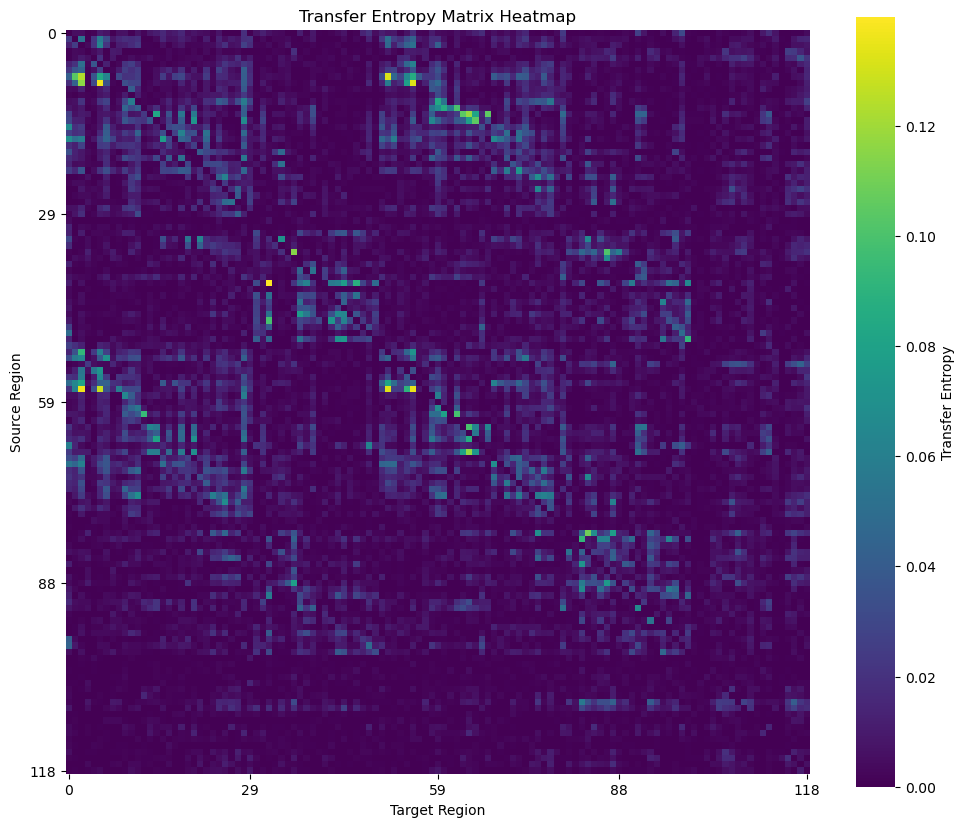

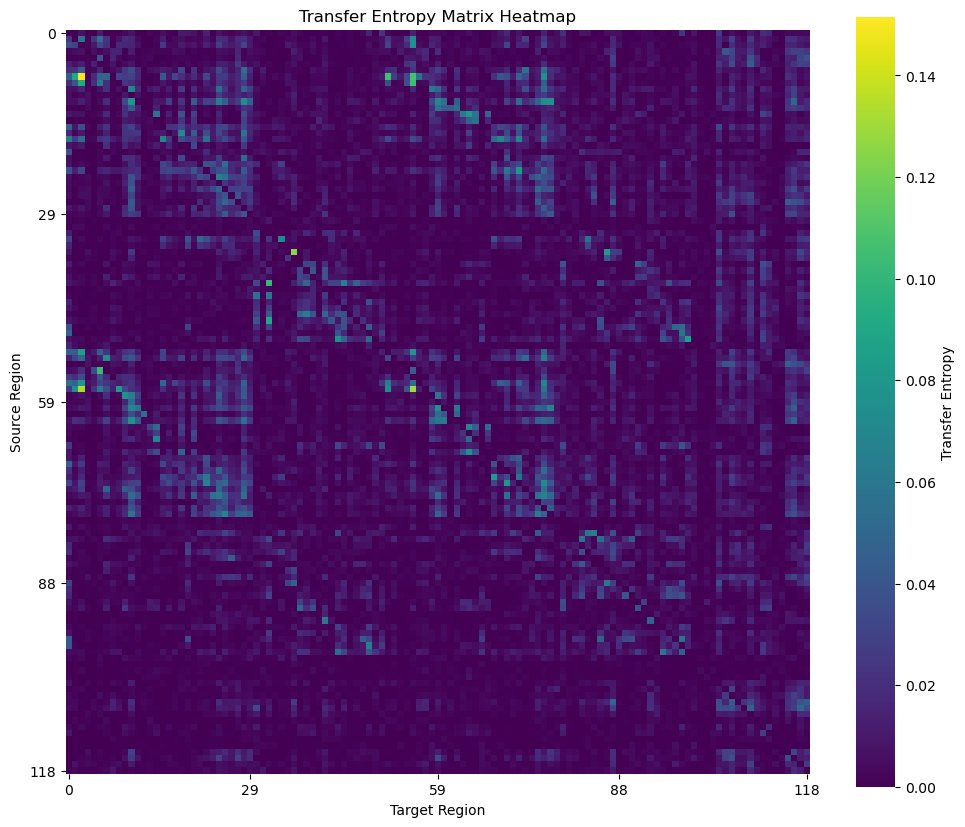

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [27]:
TE_mat_1 = nlib.transfer_entropy_matrix(data1_mat, method = "gaussian", lag=1)
TE_mat_2 = nlib.transfer_entropy_matrix(data2_mat, method = "gaussian", lag=1)
TE_heatMat(TE_mat_1, figsize=(12,10))
TE_heatMat(TE_mat_2, figsize=(12,10))

# KDE method

Transfer Entropy can be expressed in terms of conditional entropy:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

This is the **direct entropy decomposition**, equivalent to the conditional MI formulation
$I(X_t ; S_{t-\ell} \mid X_{t-1})$, but more natural for KDE-based estimation.

Using the chain rule of entropy, each conditional entropy expands as:
$$
H(X_t \mid X_{t-1}) = H(X_t, X_{t-1}) - H(X_{t-1})
$$
$$
H(X_t \mid X_{t-1}, S_{t-\ell}) = H(X_t, X_{t-1}, S_{t-\ell}) - H(X_{t-1}, S_{t-\ell})
$$

so the full expression becomes:
$$
TE = \underbrace{H(X_t, X_{t-1}, S_{t-\ell})}_{\text{3D}} 
   - \underbrace{H(X_{t-1}, S_{t-\ell})}_{\text{2D}} 
   - \underbrace{H(X_t, X_{t-1})}_{\text{2D}} 
   + \underbrace{H(X_{t-1})}_{\text{1D}}
$$

which in plug-in KDE form is:
$$
TE = -\mathbb{E}\bigl[\log_2 p(X_t, X_{t-1}, S_{t-\ell})\bigr]
   + \mathbb{E}\bigl[\log_2 p(X_{t-1}, S_{t-\ell})\bigr]
   + \mathbb{E}\bigl[\log_2 p(X_t, X_{t-1})\bigr]
   - \mathbb{E}\bigl[\log_2 p(X_{t-1})\bigr]
$$

#### Implementation

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Four KDE density estimates are computed** (plug-in: KDE fitted and evaluated on the same samples):
   - $p(X_t, X_{t-1}, S_{t-\ell})$ — 3D joint
   - $p(X_{t-1}, S_{t-\ell})$ — 2D joint
   - $p(X_t, X_{t-1})$ — 2D joint
   - $p(X_{t-1})$ — 1D marginal

3. **Transfer Entropy** is computed as the sample average:
$$
TE = \mathbb{E}\bigl[\log_2 p(X_t, X_{t-1}, S_{t-\ell}) - \log_2 p(X_{t-1}, S_{t-\ell})
   - \log_2 p(X_t, X_{t-1}) + \log_2 p(X_{t-1})\bigr]
$$

#### Notes

- Fully non-parametric: captures nonlinear dependencies without distributional assumptions.
- More flexible than Gaussian TE, but:
  - computationally expensive
  - sensitive to bandwidth selection (parameter $\alpha$)
  - the 3D KDE fit degrades with fewer than ~500 samples

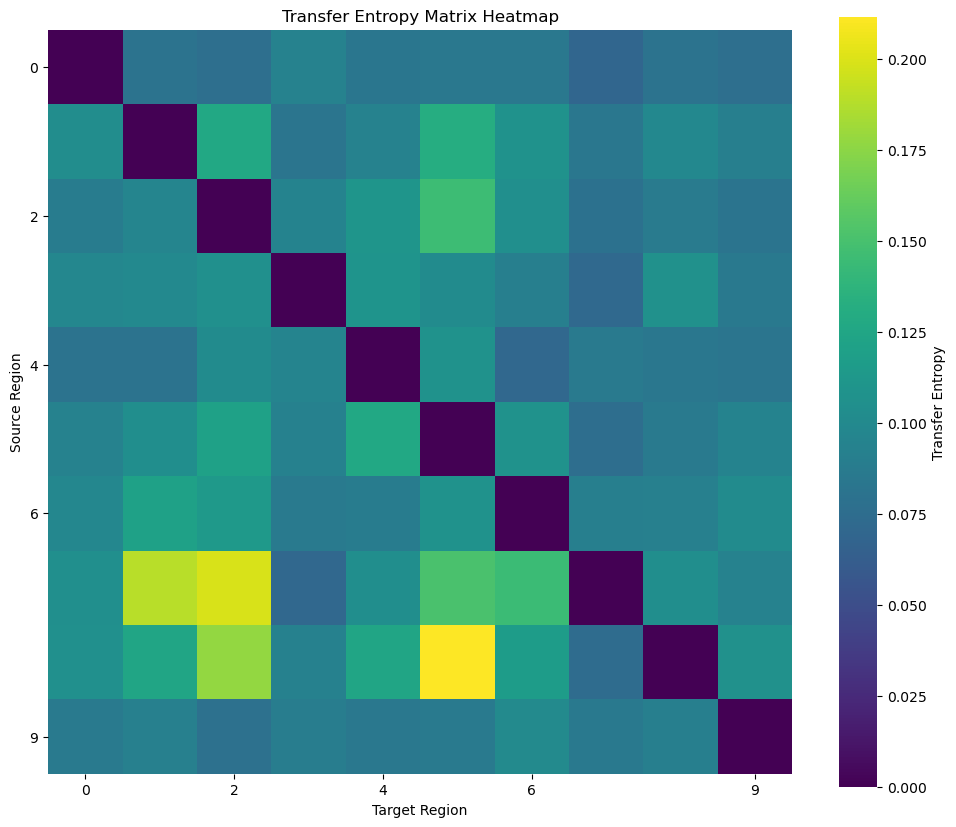

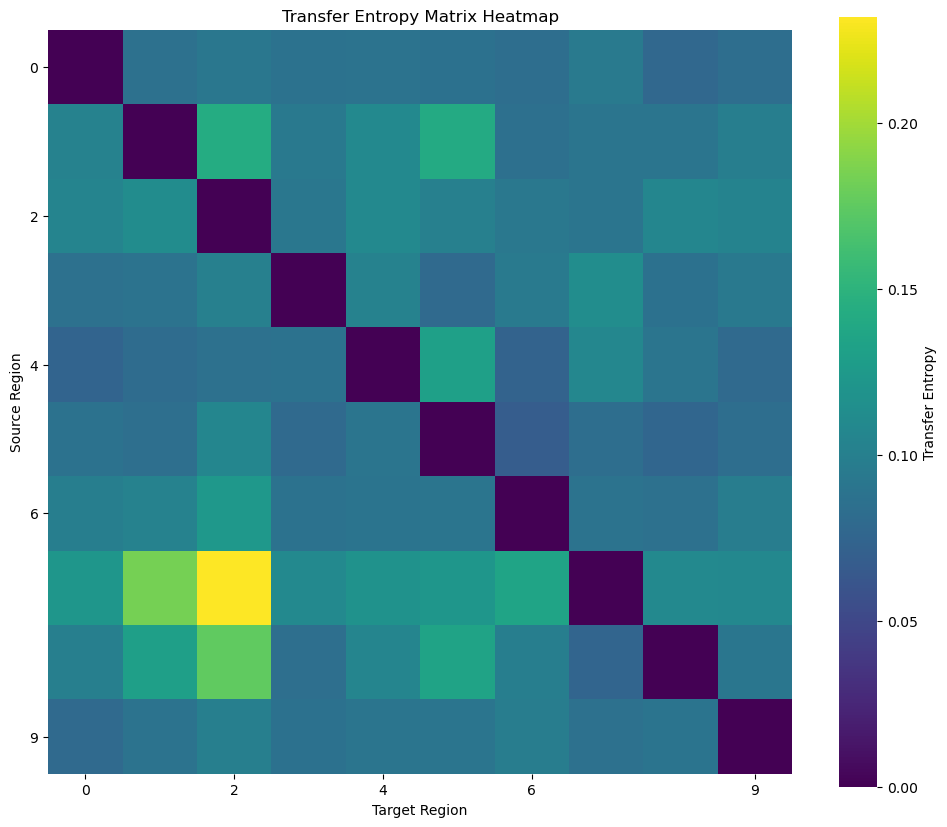

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [28]:
# NOTICE: on full data is VERY SLOW - KDE scales very badly with both sample 
#         size and dimensionality --> we reduce analysis to first 10 brain regions
TE_mat_1 = nlib.transfer_entropy_matrix(data1_mat[:10,:], method="kde", alpha=1.0)
TE_mat_2 = nlib.transfer_entropy_matrix(data2_mat[:10,:], method="kde", alpha=1.0)

TE_heatMat(TE_mat_1, figsize=(12,10))
TE_heatMat(TE_mat_2, figsize=(12,10))

# Gaussian Copula Method

The Gaussian Copula approach provides a semi-parametric method to estimate Transfer Entropy by combining:
- non-parametric marginal distributions
- Gaussian dependence modeling in a transformed space

The starting point is:
$$
TE_{S \to X} = I(X_t ; S_{t-\ell} \mid X_{t-1})
$$

Using the identity:
$$
TE = I(X_t ; S_{t-\ell}, X_{t-1}) - I(X_t ; X_{t-1})
$$

#### Implementation

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (source)
   - $X_{t-1}$ (target past)
   - $X_t$ (target)

2. **Gaussian Copula transformation:**
   - Each variable is mapped to its empirical CDF:
     $U_X = F_X(X)$
   - Then transformed to Gaussian space:
     $Z_X = \Phi^{-1}(U_X)$

   This step preserves rank structure while enforcing Gaussian marginals.

3. **Gaussian MI in transformed space:**
   - $I(X_t ; X_{t-1})$
   - $I(X_t ; X_{t-1}, S_{t-\ell})$

   are computed assuming multivariate Gaussian structure via covariance matrices.

4. **Transfer Entropy:**
$$
TE = I(X_t ; S_{t-\ell}, X_{t-1}) - I(X_t ; X_{t-1})
$$

#### Notes

- This method is **nonlinear in marginals but Gaussian in dependence structure**.
- It is more flexible than standard Gaussian TE, since:
  - marginal distributions are fully non-parametric
- Compared to KDE:
  - more stable in moderate sample sizes
  - less flexible in capturing arbitrary nonlinear dependencies
- Compared to binning:
  - avoids discretization artifacts
  - but assumes Gaussian copula structure after transformation
- Requires multivariate Gaussian MI (via covariance determinants): for jointly Gaussian variables the mutual information between a scalar variable $X$ and a vector $Y \in \mathbb{R}^d$ is given by:
$$
I(X;Y) = \frac{1}{2}\log_2 \left( \frac{\det \Sigma_X \, \det \Sigma_Y}{\det \Sigma_{XY}} \right)
$$

where:
- $\Sigma_X \in \mathbb{R}^{1 \times 1}$ is the variance of $X$,
- $\Sigma_Y \in \mathbb{R}^{d \times d}$ is the covariance matrix of $Y = (X_{t-1}, S_{t-\ell})$,
- $\Sigma_{XY} \in \mathbb{R}^{(d+1)\times(d+1)}$ is the full joint covariance matrix of $(X, Y)$.

This replaces the previous pairwise-only formula:
$$
I(X;Y) = -\frac{1}{2}\log_2(1 - \rho^2)
$$
which is valid only in the special case where both $X$ and $Y$ are scalar random variables.

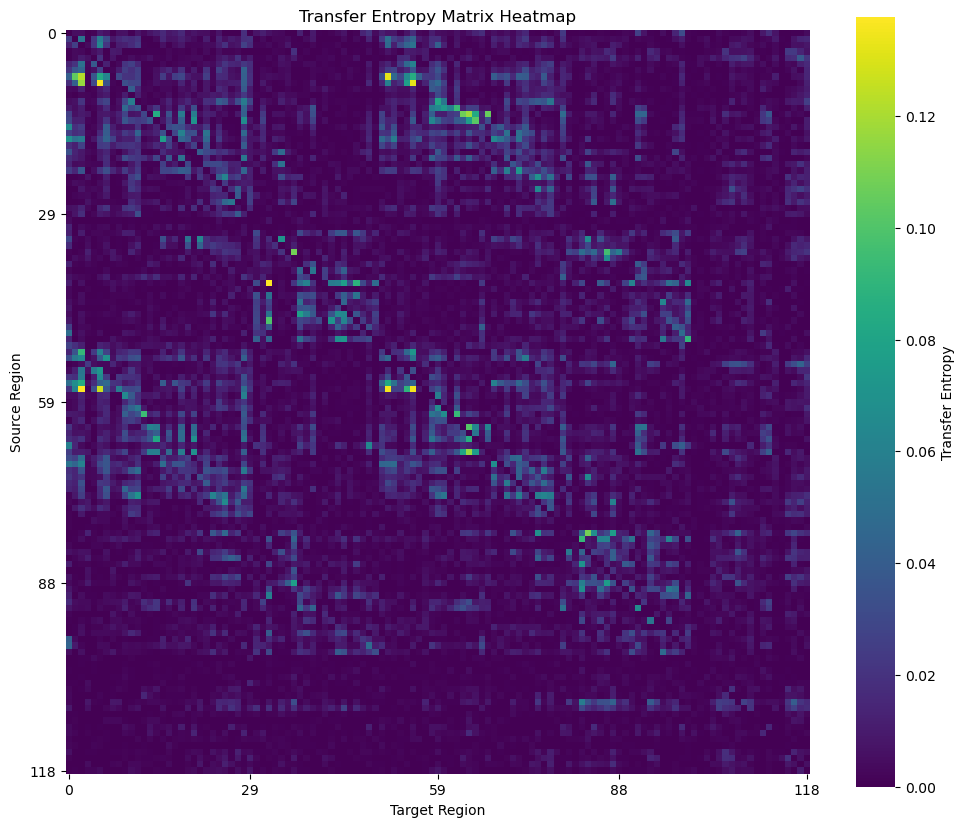

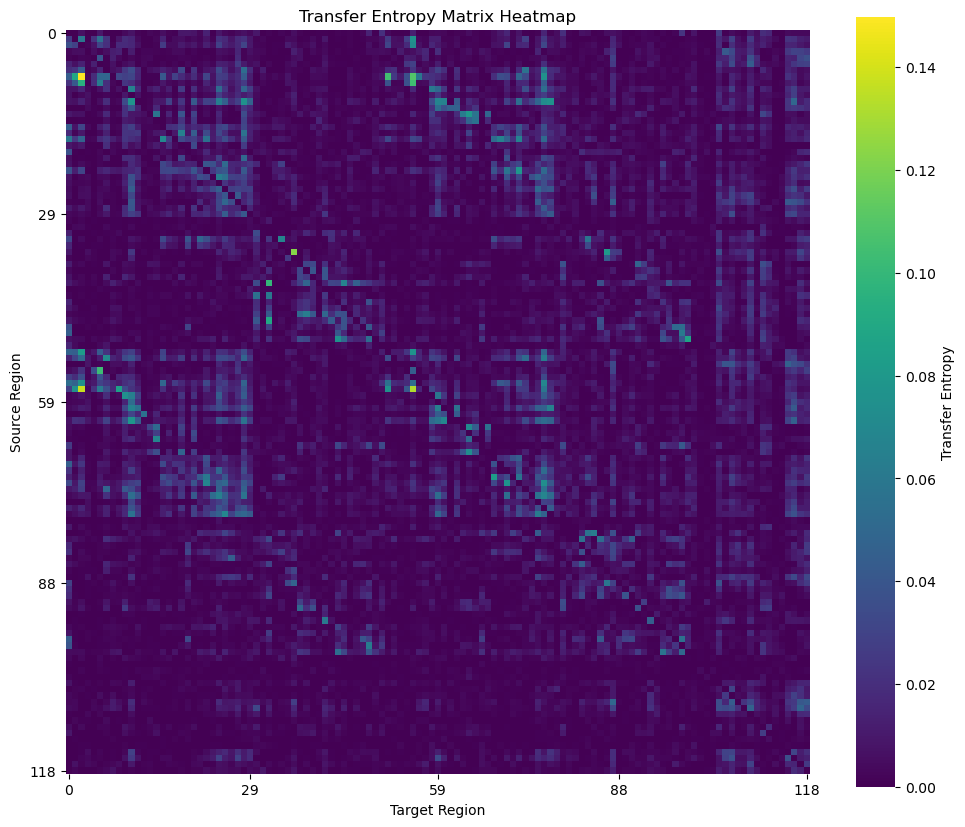

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [29]:
TE_mat_1 = nlib.transfer_entropy_matrix(data1_mat, method="copula")
TE_mat_2 = nlib.transfer_entropy_matrix(data2_mat, method="copula")

TE_heatMat(TE_mat_1, figsize=(12,10))
TE_heatMat(TE_mat_2, figsize=(12,10))